
 MONTE CARLO

DET1 : 0.074815 ± 0.000000
DET2 : 0.925185 ± 0.000000

 FINAL REALIZATION

Total traced rays: 200
DET1 hits: 100
DET2 hits: 100


===== DETECTOR DET1 =====
Hits       : 100
Bundle samples : 50
Power      : 0.500000
Intensity  : 0.074815
Phase std : 1.8674715207862387
Visibility : 0.273524


===== DETECTOR DET2 =====
Hits       : 100
Bundle samples : 50
Power      : 0.500000
Intensity  : 0.925185
Phase std : 1.689231142956937
Visibility : 0.961865


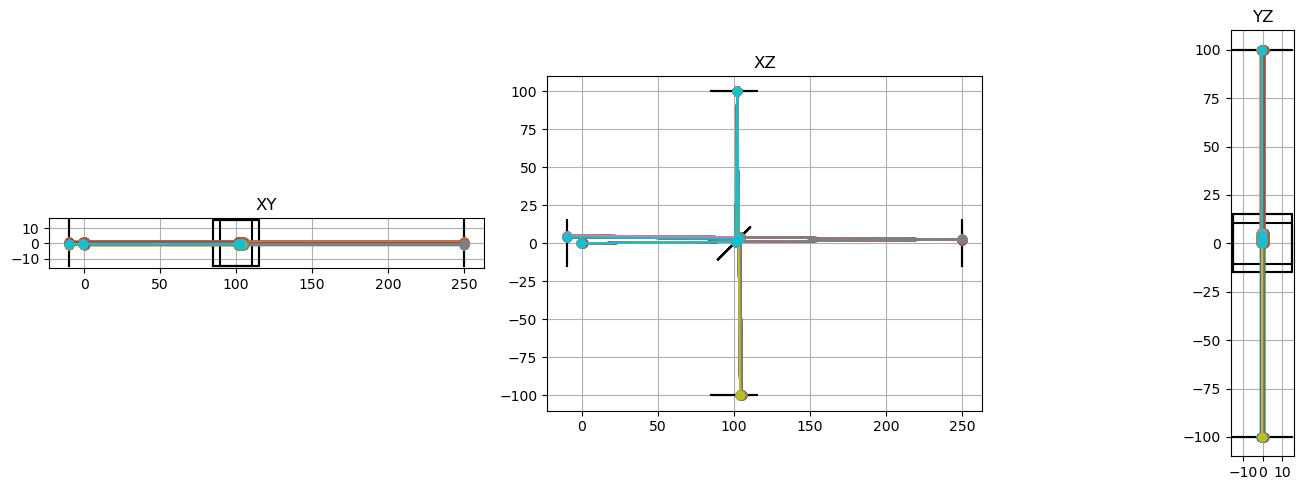

In [2]:
import numpy as np

from scipy.spatial.transform import Rotation

from system.optical_system import OpticalSystem

from optics.mirror import Mirror
from optics.beamsplitter import BeamSplitter
from optics.detector import Detector

from optics.bundle_source import CircularBundleSource

from optics.figure_error import FigureError
from plotting.views import plot_system_3views


# =====================================================
# PARAMETERS
# =====================================================

wavelength = 632.8e-9

bundle_radius = 1.0
bundle_n_rays = 50

n_mc = 10


# =====================================================
# WAVEFRONT ERRORS
# =====================================================

mirror_error = FigureError.mirror_lambda_pv(
    wavelength=wavelength,
    ratio=8,
)

bs_error = FigureError.beamsplitter_lambda_pv(
    wavelength=wavelength,
    ratio=4,
)


# =====================================================
# SYSTEM
# =====================================================

system = OpticalSystem()


# =====================================================
# MIRRORS
# =====================================================

mirror1 = Mirror(
    name="M1",

    position=[100, 0, 100],

    rotation=Rotation.identity(),

    width=30,
    height=30,

    wavefront_error=mirror_error,
)

mirror2 = Mirror(
    name="M2",

    position=[250, 0, 0],

    rotation=Rotation.from_euler(
        "y",
        -90,
        degrees=True,
    ),

    width=30,
    height=30,

    wavefront_error=mirror_error,
)


# =====================================================
# BEAM SPLITTER
# =====================================================

bs = BeamSplitter(
    name="BS",

    R=0.5,
    T=0.5,

    max_generation_depth=2,

    position=[100, 0, 0],

    rotation=Rotation.from_euler(
        "y",
        -45,
        degrees=True,
    ),

    width=30,
    height=30,

    wavefront_error=bs_error,
)


# =====================================================
# DETECTORS
# =====================================================

detector1 = Detector(
    name="DET1",

    position=[-10, 0, 0],

    rotation=Rotation.from_euler(
        "y",
        -90,
        degrees=True,
    ),

    width=30,
    height=30,
)

detector2 = Detector(
    name="DET2",

    position=[100, 0, -100],

    rotation=Rotation.identity(),

    width=30,
    height=30,
)


# =====================================================
# SOURCE
# =====================================================

source = CircularBundleSource(
    position=[0, 0, 0],

    direction=[1, 0, 0.01],

    wavelength=wavelength,

    radius=bundle_radius,

    n_rays=bundle_n_rays,
)


# =====================================================
# ASSEMBLE SYSTEM
# =====================================================

system.add_element(bs)

system.add_element(mirror1)
system.add_element(mirror2)

system.add_detector(detector1)
system.add_detector(detector2)

system.set_source(source)


# =====================================================
# MONTE CARLO
# =====================================================

det1_intensity = []
det2_intensity = []

last_rays = None

for _ in range(n_mc):

    system.randomize_wavefront_errors()

    last_rays = system.trace()

    det1_intensity.append(
        detector1.intensity
    )

    det2_intensity.append(
        detector2.intensity
    )


# =====================================================
# MONTE CARLO SUMMARY
# =====================================================

print()
print("===================================")
print(" MONTE CARLO")
print("===================================")

print()

print(
    f"DET1 : "
    f"{np.mean(det1_intensity):.6f}"
    f" ± "
    f"{np.std(det1_intensity):.6f}"
)

print(
    f"DET2 : "
    f"{np.mean(det2_intensity):.6f}"
    f" ± "
    f"{np.std(det2_intensity):.6f}"
)


# =====================================================
# FINAL REALIZATION
# =====================================================

print()
print("===================================")
print(" FINAL REALIZATION")
print("===================================")

print()

print(
    "Total traced rays:",
    system.n_rays
)

print(
    "DET1 hits:",
    len(detector1.hits)
)

print(
    "DET2 hits:",
    len(detector2.hits)
)

print()

detector1.report()

print()

detector2.report()


# =====================================================
# GEOMETRY VIEW
# =====================================================

plot_system_3views(
    system.tracer,
    last_rays,
)

In [2]:
for hit in detector1.hits[:5]:
    print(hit["position"])

[4.1000000e+00 0.0000000e+00 9.1038288e-16]
[4.1000000e+00 0.0000000e+00 9.1038288e-16]
[4.1000000e+00 0.0000000e+00 9.1038288e-16]
[4.1000000e+00 0.0000000e+00 9.1038288e-16]
[4.1000000e+00 0.0000000e+00 9.1038288e-16]


In [4]:
for ray in rays:

    print(
        ray.branch_id,
        ray.generation,
    )


root.0.T 2
root.0.R 2
root.1.T 2
root.1.R 2
root.2.T 2
root.2.R 2
root.3.T 2
root.3.R 2
root.4.T 2
root.4.R 2
root.5.T 2
root.5.R 2
root.6.T 2
root.6.R 2
root.7.T 2
root.7.R 2
root.8.T 2
root.8.R 2
root.9.T 2
root.9.R 2
root.10.T 2
root.10.R 2
root.11.T 2
root.11.R 2
root.12.T 2
root.12.R 2
root.13.T 2
root.13.R 2
root.14.T 2
root.14.R 2
root.15.T 2
root.15.R 2
root.16.T 2
root.16.R 2
root.17.T 2
root.17.R 2
root.18.T 2
root.18.R 2
root.19.T 2
root.19.R 2
root.20.T 2
root.20.R 2
root.21.T 2
root.21.R 2
root.22.T 2
root.22.R 2
root.23.T 2
root.23.R 2
root.24.T 2
root.24.R 2
root.25.T 2
root.25.R 2
root.26.T 2
root.26.R 2
root.27.T 2
root.27.R 2
root.28.T 2
root.28.R 2
root.29.T 2
root.29.R 2
root.30.T 2
root.30.R 2
root.31.T 2
root.31.R 2
root.32.T 2
root.32.R 2
root.33.T 2
root.33.R 2
root.34.T 2
root.34.R 2
root.35.T 2
root.35.R 2
root.36.T 2
root.36.R 2
root.37.T 2
root.37.R 2
root.38.T 2
root.38.R 2
root.39.T 2
root.39.R 2
root.40.T 2
root.40.R 2
root.41.T 2
root.41.R 2
root.42.T 2
